# M4-B: Suspicious Behaviour Classifier
## Training Notebook — UCF-Crime Dataset (YOLOv8-cls)

This notebook trains a **scene-level behaviour classifier** as the second channel
of M4 anomaly detection, complementing the existing rule-based loitering module (M4-A).

### System Architecture
```
M2 (YOLOv8 detection)
  └─ M3 (DeepSORT tracking)
       ├─ M4-A  Rule-based loitering  (dwell-time > 10s)       ← existing
       └─ M4-B  ML behaviour classifier  (this notebook)       ← NEW
            └─ M5 (false positive reduction — 15-frame filter)
                 └─ ALERT
```

### Target Classes (5)
| Class | UCF-Crime folder | Threat type |
|---|---|---|
| **Fighting** | `Fighting/` | Active — physical altercation |
| **Assault** | `Assault/` | Active — unprovoked attack |
| **Robbery** | `Robbery/` | Active — theft with force |
| **Vandalism** | `Vandalism/` | Active — property damage |
| **Normal** | `Normal-Videos-Part*/` | Baseline — no anomaly |

### Pipeline
1. **Preprocessing** — extract every 10th frame from each video → organised into class folders
2. **Train/Val split** — 80/20 stratified by video (not by frame, to avoid data leakage)
3. **Training** — fine-tune `yolov8n-cls.pt` on extracted frames
4. **Evaluation** — Accuracy, Precision, Recall, F1, Confusion Matrix, per-class report
5. **Export** — save best weights for integration into the main pipeline

## 0) Dependencies

In [1]:
!pip install ultralytics opencv-python numpy pandas matplotlib scikit-learn tqdm

## 0a) Download Dataset via Kaggle API

Downloads the UCF-Crime dataset directly from Kaggle using `kagglehub`.

**Prerequisites — do this once before running:**
1. Go to kaggle.com → Account → API → **Create New Token**
2. This downloads `kaggle.json` — place it at:
   - Windows: `C:\Users\<you>\.kaggle\kaggle.json`
   - Mac/Linux: `~/.kaggle/kaggle.json`
3. Run the cell below — the dataset downloads to a local cache folder

The downloaded path is automatically set as `DATASET_ROOT` in Section 1.

In [ ]:
# !pip install kagglehub   # uncomment if not installed

import kagglehub

print('Downloading UCF-Crime dataset from Kaggle...')
print('(First run: ~several GB download — subsequent runs use cache)')
print()

kaggle_path = kagglehub.dataset_download("mission-ai/crimeucfdataset")

print()
print(f'✅ Dataset downloaded to: {kaggle_path}')
print()

# Show top-level folder structure
import os
from pathlib import Path
top = Path(kaggle_path)
print('Folder structure:')
for item in sorted(top.rglob('*')):
    if item.is_dir():
        depth = len(item.relative_to(top).parts)
        if depth <= 3:
            indent = '  ' * depth
            n_files = len(list(item.glob('*.*')))
            print(f'{indent}{item.name}/  ({n_files} files)')

# ── Auto-set DATASET_ROOT for Section 1 ─────────────────────────────────────
DATASET_ROOT = str(top)
print()
print(f'DATASET_ROOT set to: {DATASET_ROOT}')
print('This will be used automatically in Section 1 below.')

## 1) Configuration

In [1]:
import os, cv2, gc, shutil, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from collections import defaultdict
from tqdm import tqdm

# ── EDIT THESE ───────────────────────────────────────────────────────────────

# Root of the downloaded Anomaly_Dataset folder
if 'DATASET_ROOT' not in dir() or not os.path.exists(DATASET_ROOT):
    DATASET_ROOT = r'../Anomaly_Videos'   # ← edit if not using kagglehub

# Where to write extracted frames (will be created automatically)
FRAMES_ROOT  = r'../M4B_frames'

# Where YOLO training output goes
TRAIN_OUTPUT = r'runs/M4B_classifier'

# ── 3 classes (adjust if you have more videos) ────────────────────────────────
TARGET_CLASSES = ['Fighting', 'Assault', 'Normal']

# Frame extraction settings
FRAME_STRIDE         = 15     # 1 frame every N frames (~2-3 fps at 25fps)
TRAIN_RATIO           = 0.80   # 80/20 split BY VIDEO (prevents data leakage)
MAX_FRAMES_PER_CLASS = {
    'Assault':  13000,   # use almost all — it's the smallest class
    'Fighting': 13000,   # cap to match Assault
    'Normal':   13000,   # cap heavily (was 64,952)
}

# Base model (shared across all experiments)
BASE_MODEL = 'yolov8n-cls.pt'
# For your RTX 4060 laptop, 8 workers is a reasonable starting point
WORKERS = 8

# ── Ablation experiment grid ──────────────────────────────────────────────────
# 4 runs that give you a hyperparameter sensitivity table for your FYP write-up
EXPERIMENTS = [
    {
        'name': 'Run1_Baseline',
        'epochs': 20, 'lr0': 0.01, 'batch': 32,
        'imgsz': 224, 'dropout': 0.0, 'patience': 7,
        'description': 'Baseline',
    },
    {
        'name': 'Run2_LowLR',
        'epochs': 20, 'lr0': 0.001, 'batch': 32,
        'imgsz': 224, 'dropout': 0.0, 'patience': 7,
        'description': 'Lower learning rate',
    },
    {
        'name': 'Run3_Dropout',
        'epochs': 20, 'lr0': 0.001, 'batch': 32,
        'imgsz': 224, 'dropout': 0.3, 'patience': 7,
        'description': 'Low LR + dropout',
    },
    {
        'name': 'Run4_LargerImg',
        'epochs': 20, 'lr0': 0.001, 'batch': 16,
        'imgsz': 320, 'dropout': 0.3, 'patience': 7,
        'description': 'Low LR + dropout + larger image',
    },
]

# ── Verify dataset root ───────────────────────────────────────────────────────
if os.path.exists(DATASET_ROOT):
    print(f'✅ DATASET_ROOT found: {DATASET_ROOT}')
    for p in sorted(Path(DATASET_ROOT).iterdir()):
        if p.is_dir():
            sub = [s.name for s in p.iterdir() if s.is_dir()]
            print(f'   {p.name}/ → {sub[:6]}{"..." if len(sub)>6 else ""}')
else:
    print(f'❌ DATASET_ROOT not found: {DATASET_ROOT}')

print()
print(f'Ablation experiments configured: {len(EXPERIMENTS)}')
print(f'{"Run":<22} {"epochs":>7} {"lr0":>8} {"batch":>6} {"imgsz":>6} {"dropout":>8}  Description')
print('-'*80)
for e in EXPERIMENTS:
    print(f'  {e["name"]:<20} {e["epochs"]:>7} {e["lr0"]:>8.4f} '
          f'{e["batch"]:>6} {e["imgsz"]:>6} {e["dropout"]:>8.1f}  {e["description"]}')

✅ DATASET_ROOT found: ../Anomaly_Videos
   Anomaly-Videos-Part-1/ → ['Abuse', 'Arrest', 'Arson', 'Assault']
   Anomaly-Videos-Part-2/ → ['Burglary', 'Explosion', 'Fighting']
   Normal-Videos-Part-1/ → []

Ablation experiments configured: 4
Run                     epochs      lr0  batch  imgsz  dropout  Description
--------------------------------------------------------------------------------
  Run1_Baseline             20   0.0100     32    224      0.0  Baseline
  Run2_LowLR                20   0.0010     32    224      0.0  Lower learning rate
  Run3_Dropout              20   0.0010     32    224      0.3  Low LR + dropout
  Run4_LargerImg            20   0.0010     16    320      0.3  Low LR + dropout + larger image


## 2) Dataset Exploration
Scan available videos per class before extraction.

In [2]:
def find_class_videos(dataset_root, class_name):
    """
    Find all .mp4/.avi video files for a given class name.
    Searches recursively — handles Part1/Part2/... splits.
    For 'Normal', searches all Normal-Videos-* folders.
    """
    root = Path(dataset_root)
    videos = []

    if class_name.lower() == 'normal':
        # Normal videos spread across Normal-Videos-Part1, Part2...
        for folder in root.rglob('*'):
            if folder.is_dir() and 'normal' in folder.name.lower():
                for ext in ['*.mp4','*.avi','*.MP4','*.AVI']:
                    videos.extend(folder.glob(ext))
    else:
        for folder in root.rglob('*'):
            if folder.is_dir() and folder.name == class_name:
                for ext in ['*.mp4','*.avi','*.MP4','*.AVI']:
                    videos.extend(folder.glob(ext))

    return sorted(set(videos))


# ── Scan all target classes ───────────────────────────────────────────────────
print('Scanning dataset...')
print()
print(f'  {"Class":<14} {"Videos":>8} {"Est. frames":>14}  Folder(s)')
print(f'  {"-"*70}')

class_videos = {}
total_videos = 0
total_frames_est = 0

for cls in TARGET_CLASSES:
    vids = find_class_videos(DATASET_ROOT, cls)
    class_videos[cls] = vids
    # Estimate frame count: assume avg 5 min video @ 25fps / FRAME_STRIDE
    est = len(vids) * 300 * 25 // FRAME_STRIDE
    total_videos += len(vids)
    total_frames_est += est
    # Show unique parent folders
    parents = set(v.parent.name for v in vids)
    print(f'  {cls:<14} {len(vids):>8,} {est:>14,}  {list(parents)[:3]}')

print(f'  {"-"*70}')
print(f'  {"TOTAL":<14} {total_videos:>8,} {total_frames_est:>14,}')
print()
print('NOTE: Frame count is an estimate. Actual depends on video length.')

Scanning dataset...

  Class            Videos    Est. frames  Folder(s)
  ----------------------------------------------------------------------
  Fighting             50         25,000  ['Fighting']
  Assault              50         25,000  ['Assault']
  Normal              150         75,000  ['Normal-Videos-Part-1']
  ----------------------------------------------------------------------
  TOTAL               250        125,000

NOTE: Frame count is an estimate. Actual depends on video length.


In [3]:
# ==========================================
# DATASET DETAIL SUMMARY (videos + frames)
# ==========================================
import os
import cv2
import math
import pandas as pd
from pathlib import Path

def bytes_to_mb(x):
    return x / (1024 * 1024)

def bytes_to_gb(x):
    return x / (1024 * 1024 * 1024)

def get_video_info(video_path):
    cap = cv2.VideoCapture(str(video_path))

    if not cap.isOpened():
        return {
            "video_name": video_path.name,
            "class": video_path.parent.name,
            "path": str(video_path),
            "file_size_mb": round(bytes_to_mb(video_path.stat().st_size), 2),
            "width": None,
            "height": None,
            "resolution": None,
            "fps": None,
            "total_frames": None,
            "duration_sec": None,
            "duration_min": None,
            "estimated_extracted_frames": None,
            "readable": False
        }

    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    cap.release()

    duration_sec = total_frames / fps if fps and fps > 0 else None
    duration_min = duration_sec / 60 if duration_sec is not None else None

    est_extracted = math.ceil(total_frames / FRAME_STRIDE) if total_frames else 0

    return {
        "video_name": video_path.name,
        "class": video_path.parent.name,
        "path": str(video_path),
        "file_size_mb": round(bytes_to_mb(video_path.stat().st_size), 2),
        "width": width,
        "height": height,
        "resolution": f"{width}x{height}" if width and height else None,
        "fps": round(fps, 2) if fps else None,
        "total_frames": total_frames,
        "duration_sec": round(duration_sec, 2) if duration_sec is not None else None,
        "duration_min": round(duration_min, 2) if duration_min is not None else None,
        "estimated_extracted_frames": est_extracted,
        "readable": True
    }

# ---- collect all target videos ----
all_video_rows = []

for cls in TARGET_CLASSES:
    vids = find_class_videos(DATASET_ROOT, cls)
    print(f"Scanning {cls}: {len(vids)} videos")
    for vp in vids:
        row = get_video_info(vp)
        row["target_class"] = cls   # use your intended class label
        all_video_rows.append(row)

video_df = pd.DataFrame(all_video_rows)

# ---- show per-video details ----
print("\n==============================")
print("PER-VIDEO DATASET DETAILS")
print("==============================")
display(video_df.head(20))   # show first 20 rows
print(f"\nTotal videos found: {len(video_df):,}")

# ---- class-level summary ----
class_summary = (
    video_df.groupby("target_class", dropna=False)
    .agg(
        videos=("video_name", "count"),
        total_file_size_mb=("file_size_mb", "sum"),
        avg_file_size_mb=("file_size_mb", "mean"),
        total_frames=("total_frames", "sum"),
        avg_frames=("total_frames", "mean"),
        avg_fps=("fps", "mean"),
        avg_duration_sec=("duration_sec", "mean"),
        total_duration_min=("duration_min", "sum"),
        avg_width=("width", "mean"),
        avg_height=("height", "mean"),
        estimated_extracted_frames=("estimated_extracted_frames", "sum")
    )
    .reset_index()
)

class_summary["total_file_size_gb"] = class_summary["total_file_size_mb"] / 1024
class_summary["avg_file_size_mb"] = class_summary["avg_file_size_mb"].round(2)
class_summary["avg_frames"] = class_summary["avg_frames"].round(2)
class_summary["avg_fps"] = class_summary["avg_fps"].round(2)
class_summary["avg_duration_sec"] = class_summary["avg_duration_sec"].round(2)
class_summary["total_duration_min"] = class_summary["total_duration_min"].round(2)
class_summary["avg_width"] = class_summary["avg_width"].round(0)
class_summary["avg_height"] = class_summary["avg_height"].round(0)
class_summary["total_file_size_gb"] = class_summary["total_file_size_gb"].round(2)

print("\n==============================")
print("CLASS-LEVEL SUMMARY")
print("==============================")
display(class_summary)

# ---- overall dataset summary ----
overall_summary = {
    "total_videos": len(video_df),
    "total_file_size_mb": round(video_df["file_size_mb"].sum(), 2),
    "total_file_size_gb": round(video_df["file_size_mb"].sum() / 1024, 2),
    "total_frames": int(video_df["total_frames"].fillna(0).sum()),
    "total_duration_min": round(video_df["duration_min"].fillna(0).sum(), 2),
    "avg_fps": round(video_df["fps"].dropna().mean(), 2),
    "estimated_extracted_frames": int(video_df["estimated_extracted_frames"].fillna(0).sum())
}

print("\n==============================")
print("OVERALL DATASET SUMMARY")
print("==============================")
for k, v in overall_summary.items():
    print(f"{k}: {v}")

Scanning Fighting: 50 videos
Scanning Assault: 50 videos
Scanning Normal: 150 videos

PER-VIDEO DATASET DETAILS


,video_name,class,path,file_size_mb,width,height,resolution,fps,total_frames,duration_sec,duration_min,estimated_extracted_frames,readable,target_class
0,Fighting002_x264.mp4,Fighting,..\Anomaly_Videos\Anomaly-Videos-Part-2\Fighti...,16.17,320,240,320x240,30.0,2688,89.60,1.49,180,True,Fighting
1,Fighting003_x264.mp4,Fighting,..\Anomaly_Videos\Anomaly-Videos-Part-2\Fighti...,26.78,320,240,320x240,30.0,3102,103.40,1.72,207,True,Fighting
2,Fighting004_x264.mp4,Fighting,..\Anomaly_Videos\Anomaly-Videos-Part-2\Fighti...,116.12,320,240,320x240,30.0,16777,559.23,9.32,1119,True,Fighting
3,Fighting005_x264.mp4,Fighting,..\Anomaly_Videos\Anomaly-Videos-Part-2\Fighti...,8.14,320,240,320x240,30.0,1784,59.47,0.99,119,True,Fighting
4,Fighting006_x264.mp4,Fighting,..\Anomaly_Videos\Anomaly-Videos-Part-2\Fighti...,8.72,320,240,320x240,30.0,944,31.47,0.52,63,True,Fighting
5,Fighting007_x264.mp4,Fighting,..\Anomaly_Videos\Anomaly-Videos-Part-2\Fighti...,29.89,320,240,320x240,30.0,3794,126.47,2.11,253,True,Fighting
6,Fighting008_x264.mp4,Fighting,..\Anomaly_Videos\Anomaly-Videos-Part-2\Fighti...,105.71,320,240,320x240,30.0,13134,437.80,7.30,876,True,Fighting
7,Fighting009_x264.mp4,Fighting,..\Anomaly_Videos\Anomaly-Videos-Part-2\Fighti...,17.03,320,240,320x240,30.0,2132,71.07,1.18,143,True,Fighting
8,Fighting010_x264.mp4,Fighting,..\Anomaly_Videos\Anomaly-Videos-Part-2\Fighti...,43.49,320,240,320x240,30.0,5865,195.50,3.26,391,True,Fighting
9,Fighting011_x264.mp4,Fighting,..\Anomaly_Videos\Anomaly-Videos-Part-2\Fighti...,65.82,320,240,320x240,30.0,8240,274.67,4.58,550,True,Fighting



Total videos found: 250

CLASS-LEVEL SUMMARY


,target_class,videos,total_file_size_mb,avg_file_size_mb,total_frames,avg_frames,avg_fps,avg_duration_sec,total_duration_min,avg_width,avg_height,estimated_extracted_frames,total_file_size_gb
0,Assault,50,944.08,18.88,129946,2598.92,30.0,86.63,72.18,320.0,240.0,8688,0.92
1,Fighting,50,1937.19,38.74,258895,5177.90,30.0,172.60,143.82,320.0,240.0,17284,1.89
2,Normal,150,4520.89,30.14,648905,4326.03,30.0,144.20,360.50,320.0,240.0,43319,4.41



OVERALL DATASET SUMMARY
total_videos: 250
total_file_size_mb: 7402.16
total_file_size_gb: 7.23
total_frames: 1037746
total_duration_min: 576.5
avg_fps: 30.0
estimated_extracted_frames: 69291


## 3) Frame Extraction

Extracts frames from each video at `FRAME_STRIDE` interval.

**Important — split is done BY VIDEO (not by frame):**
- 80% of videos → `train/ClassName/`
- 20% of videos → `val/ClassName/`

This prevents data leakage where consecutive frames from the same video
appear in both train and val sets.

In [4]:
def extract_frames_for_class(videos, class_name, frames_root,
                             stride, train_ratio,
                             max_frames=None, seed=42):
    """
    Extract frames from a list of videos, split by video into train/val.
    Saves to:  frames_root/train/class_name/video_name_frameXXXX.jpg
               frames_root/val/class_name/video_name_frameXXXX.jpg
    """
    random.seed(seed)
    shuffled = list(videos)
    random.shuffle(shuffled)

    n_train = max(1, int(len(shuffled) * train_ratio))
    train_vids = shuffled[:n_train]
    val_vids   = shuffled[n_train:]

    stats = {'train_frames':0, 'val_frames':0,
             'train_videos':len(train_vids), 'val_videos':len(val_vids),
             'skipped':0}

    for split, vid_list in [('train', train_vids), ('val', val_vids)]:
        out_dir = Path(frames_root) / split / class_name
        out_dir.mkdir(parents=True, exist_ok=True)

        for vpath in vid_list:
            cap = cv2.VideoCapture(str(vpath))
            if not cap.isOpened():
                stats['skipped'] += 1
                continue

            f_i = 0
            saved = 0
            stem = vpath.stem[:30]   # truncate long filenames

            while True:
                ret, frame = cap.read()
                if not ret: break

                if f_i % stride == 0:
                    fname = out_dir / f'{stem}_f{f_i:05d}.jpg'
                    cv2.imwrite(str(fname), frame,
                                [cv2.IMWRITE_JPEG_QUALITY, 90])
                    saved += 1

                    # Check class-level frame cap
                    total_so_far = stats['train_frames'] + stats['val_frames']
                    if max_frames and total_so_far >= max_frames:
                        cap.release()
                        return stats

                f_i += 1
            cap.release()

            if split == 'train': stats['train_frames'] += saved
            else:                stats['val_frames']   += saved

    return stats


# ── Run extraction for all classes ────────────────────────────────────────────
print(f'Extracting frames to: {FRAMES_ROOT}')
print(f'Frame stride: every {FRAME_STRIDE} frames')
print(f'Train/Val split: {int(TRAIN_RATIO*100)}/{int((1-TRAIN_RATIO)*100)} by video')
if MAX_FRAMES_PER_CLASS:
    print(f'Max frames/class: {MAX_FRAMES_PER_CLASS}')
print()

extraction_stats = {}

for cls in TARGET_CLASSES:
    vids = class_videos.get(cls, [])
    if not vids:
        print(f'⚠️  {cls}: no videos found — skipping')
        continue

    # ── pull the per-class cap correctly ──────────────────────
    if isinstance(MAX_FRAMES_PER_CLASS, dict):
        cap = MAX_FRAMES_PER_CLASS.get(cls, None)
    else:
        cap = MAX_FRAMES_PER_CLASS   # handles None or int fallback

    print(f'  Extracting {cls} ({len(vids)} videos)...', end=' ')
    stats = extract_frames_for_class(
        videos      = vids,
        class_name  = cls,
        frames_root = FRAMES_ROOT,
        stride      = FRAME_STRIDE,
        train_ratio = TRAIN_RATIO,
        max_frames  = cap,           # ← pass the per-class value
    )
    extraction_stats[cls] = stats
    print(f'train={stats["train_frames"]:,}  val={stats["val_frames"]:,}  '
          f'(videos: {stats["train_videos"]}t / {stats["val_videos"]}v)')

# ── Summary table ─────────────────────────────────────────────────────────────
print()
print('='*65)
print(f'  {"Class":<14} {"Train frames":>14} {"Val frames":>12} {"Total":>10}')
print(f'  {"-"*54}')
t_tr = t_va = 0
for cls, s in extraction_stats.items():
    tr, va = s['train_frames'], s['val_frames']
    t_tr += tr; t_va += va
    print(f'  {cls:<14} {tr:>14,} {va:>12,} {tr+va:>10,}')
print(f'  {"-"*54}')
print(f'  {"TOTAL":<14} {t_tr:>14,} {t_va:>12,} {t_tr+t_va:>10,}')
print('='*65)

Extracting frames to: ../M4B_frames
Frame stride: every 15 frames
Train/Val split: 80/19 by video
Max frames/class: {'Assault': 13000, 'Fighting': 13000, 'Normal': 13000}

  Extracting Fighting (50 videos)... train=13,717  val=0  (videos: 40t / 10v)
  Extracting Assault (50 videos)... train=5,879  val=2,809  (videos: 40t / 10v)
  Extracting Normal (150 videos)... train=16,101  val=0  (videos: 120t / 30v)

  Class            Train frames   Val frames      Total
  ------------------------------------------------------
  Fighting               13,717            0     13,717
  Assault                 5,879        2,809      8,688
  Normal                 16,101            0     16,101
  ------------------------------------------------------
  TOTAL                  35,697        2,809     38,506


## 4) Class Balance Check
Verify extracted frames and visualise class distribution.

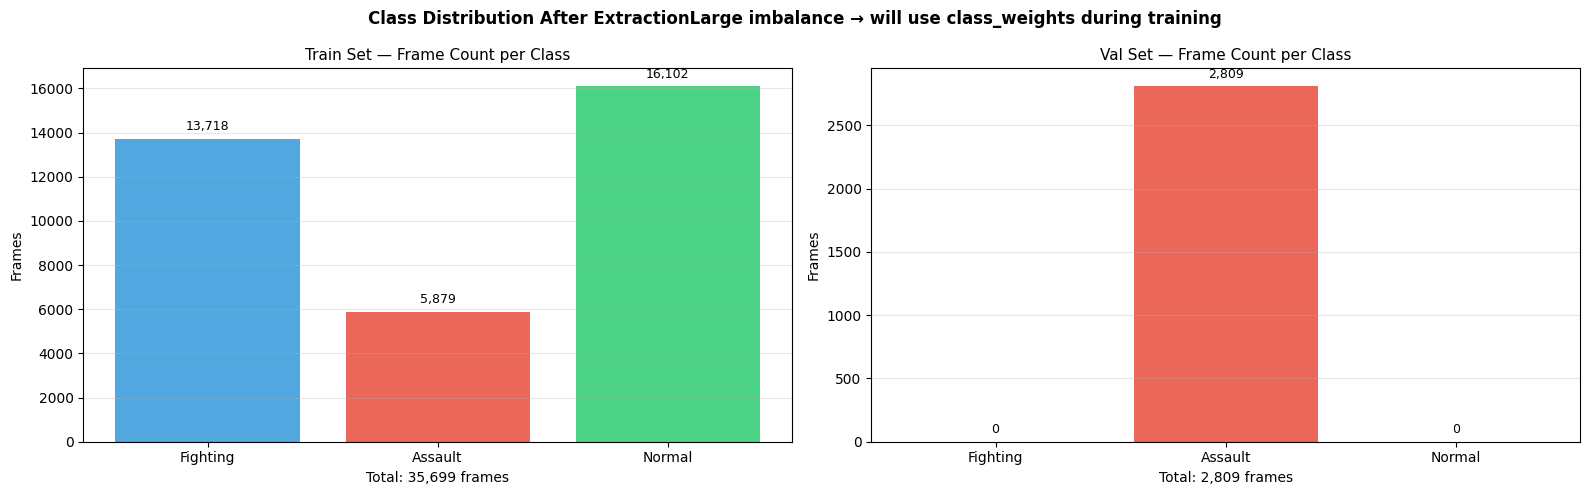

Imbalance ratio (max/min): 2.7x
✅ Moderate imbalance — class weights applied as precaution


In [5]:
# Count actual files on disk
actual_counts = {'train':{}, 'val':{}}
for split in ['train','val']:
    for cls in TARGET_CLASSES:
        d = Path(FRAMES_ROOT) / split / cls
        if d.exists():
            actual_counts[split][cls] = len(list(d.glob('*.jpg')))
        else:
            actual_counts[split][cls] = 0

# Bar chart
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
colors = ['#3498DB','#E74C3C','#2ECC71','#F39C12','#9B59B6']

for ax, split in zip(axes, ['train','val']):
    counts = [actual_counts[split].get(c,0) for c in TARGET_CLASSES]
    bars = ax.bar(TARGET_CLASSES, counts, color=colors, alpha=0.85)
    ax.bar_label(bars, labels=[f'{v:,}' for v in counts], padding=4, fontsize=9)
    ax.set_title(f'{split.capitalize()} Set — Frame Count per Class', fontsize=11)
    ax.set_ylabel('Frames')
    ax.grid(axis='y', alpha=0.3)
    total = sum(counts)
    ax.set_xlabel(f'Total: {total:,} frames', fontsize=10)

plt.suptitle('Class Distribution After Extraction'
             'Large imbalance → will use class_weights during training',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Check imbalance ratio
train_counts = [actual_counts['train'].get(c,1) for c in TARGET_CLASSES]
ratio = max(train_counts) / max(min(train_counts), 1)
print(f'Imbalance ratio (max/min): {ratio:.1f}x')
if ratio > 5:
    print('⚠️  High imbalance — class weights will be applied automatically')
else:
    print('✅ Moderate imbalance — class weights applied as precaution')

## 5) Sample Frames Preview
Visual sanity check — 3 random frames from each class.

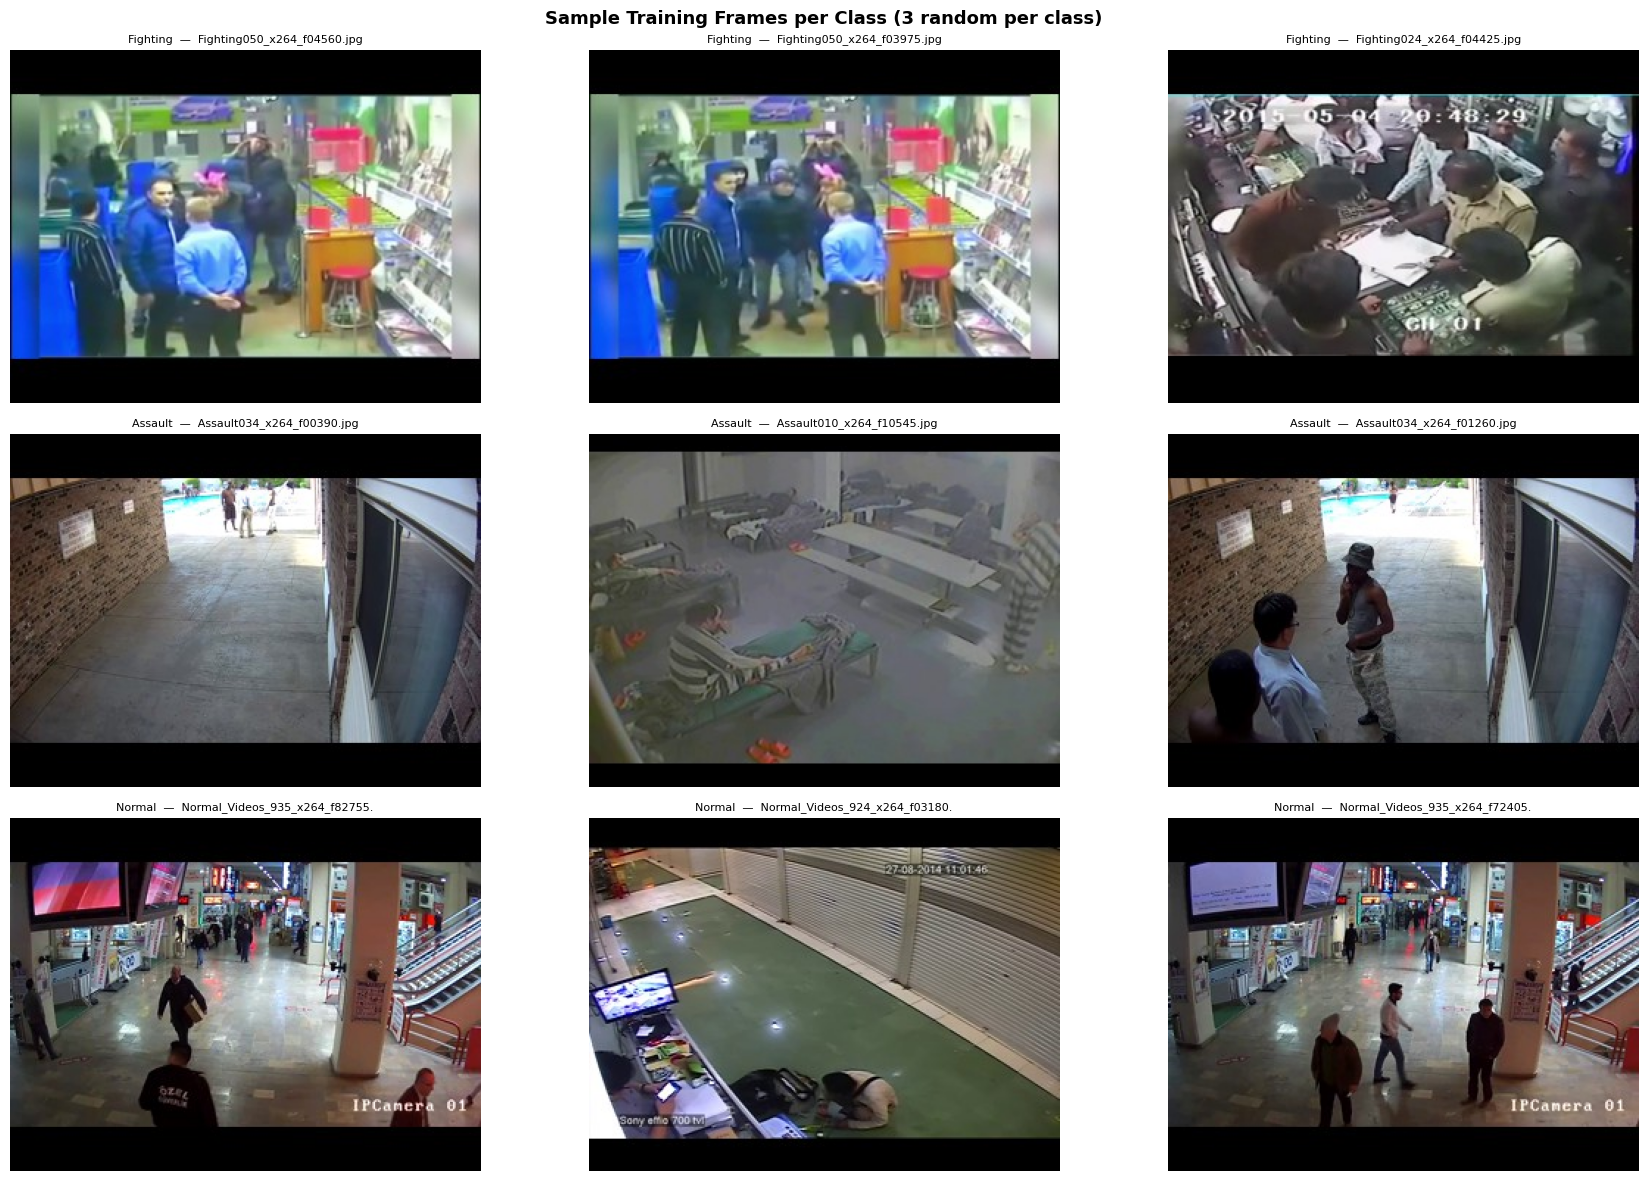

In [6]:
fig, axes = plt.subplots(len(TARGET_CLASSES), 3,
                         figsize=(18, 4*len(TARGET_CLASSES)))

for row, cls in enumerate(TARGET_CLASSES):
    cls_dir = Path(FRAMES_ROOT) / 'train' / cls
    frames_available = list(cls_dir.glob('*.jpg')) if cls_dir.exists() else []

    picks = random.sample(frames_available, min(3, len(frames_available)))
    while len(picks) < 3:
        picks.append(None)

    for col, fpath in enumerate(picks):
        ax = axes[row][col]
        if fpath and fpath.exists():
            img = cv2.cvtColor(cv2.imread(str(fpath)), cv2.COLOR_BGR2RGB)
            ax.imshow(img)
            ax.set_title(f'{cls}  —  {fpath.name[:30]}', fontsize=8)
        else:
            ax.text(0.5, 0.5, 'No frame', ha='center', va='center',
                    transform=ax.transAxes, fontsize=12, color='grey')
        ax.axis('off')

plt.suptitle('Sample Training Frames per Class (3 random per class)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 6) Training — YOLOv8-cls Fine-tuning

Fine-tunes `yolov8n-cls.pt` (nano classification model) on the extracted frames.

**Why YOLOv8-cls?**
- Same YOLO ecosystem as your M2 detector — consistent toolchain
- Fast inference — can run in real-time alongside M2+M3
- `yolov8n-cls` is ~2MB and runs at >100fps on CPU

**Class weighting:** automatically computed from frame counts to
handle the Normal class dominance.

In [8]:
# !pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128

In [7]:
import torch

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version used by torch:", torch.version.cuda)
print("GPU count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

Torch version: 2.10.0+cu128
CUDA available: True
CUDA version used by torch: 12.8
GPU count: 1
GPU name: NVIDIA GeForce RTX 4060 Laptop GPU


In [8]:
from ultralytics import YOLO
from sklearn.metrics import accuracy_score, f1_score
from pathlib import Path
import time
import torch
import gc
import random
import numpy as np
import pandas as pd

# ── CUDA / device detection ───────────────────────────────────────────────────
if torch.cuda.is_available():
    DEVICE = 'cuda'
    GPU_NAME = torch.cuda.get_device_name(0)
    VRAM_GB = torch.cuda.get_device_properties(0).total_memory / 1e9
    GPU_BATCH_SCALE = max(1, int(VRAM_GB / 4))
    torch.backends.cudnn.benchmark = True

    print(f'✅ CUDA available: {GPU_NAME} ({VRAM_GB:.1f} GB VRAM)')
    print(f'   Batch scale factor: {GPU_BATCH_SCALE}x')
elif torch.backends.mps.is_available():
    DEVICE = 'mps'
    GPU_BATCH_SCALE = 1
    print('✅ Apple MPS available — using GPU acceleration')
else:
    DEVICE = 'cpu'
    GPU_BATCH_SCALE = 1
    print('⚠️ No GPU detected — training on CPU')

print(f'\nDevice : {DEVICE}')
print(f'Workers: {WORKERS}')


def get_device_batch(base_batch):
    """Scale batch size up for CUDA, keep as-is otherwise."""
    if DEVICE == 'cuda':
        return min(base_batch * GPU_BATCH_SCALE, 128)
    return base_batch


def fmt_time(seconds):
    m, s = divmod(int(seconds), 60)
    h, m = divmod(m, 60)
    if h > 0:
        return f'{h}h{m:02d}m'
    return f'{m}m{s:02d}s'


def make_progress_callback(total_epochs, t0_ref):
    """
    Print one clean line after each epoch:
    [██████░░░░] ep/total (%)  loss  val_acc  lr  elapsed  ETA
    """
    def on_epoch_end(trainer):
        ep = trainer.epoch + 1
        elapsed = time.time() - t0_ref[0]
        avg_epoch_time = elapsed / ep
        eta = avg_epoch_time * (total_epochs - ep)

        metrics = trainer.metrics or {}
        loss_val = getattr(trainer, 'loss', None)

        top1 = metrics.get(
            'metrics/accuracy_top1',
            metrics.get(
                'val/acc_top1',
                metrics.get('metrics/acc_top1', float('nan'))
            )
        )

        lr_now = (
            trainer.optimizer.param_groups[0]['lr']
            if trainer.optimizer else float('nan')
        )

        stopper = getattr(trainer, 'stopper', None)
        patience_str = ''
        if stopper is not None and getattr(stopper, 'possible_stop', False):
            patience_str = '  ⚠️ patience'

        filled = int(28 * ep / total_epochs)
        bar = '█' * filled + '░' * (28 - filled)
        pct = 100 * ep / total_epochs

        loss_s = f'{float(loss_val):.4f}' if loss_val is not None else '—'
        top1_s = f'{top1:.4f}' if top1 == top1 else '—'  # NaN-safe

        print(
            f'  [{bar}] {ep:>3}/{total_epochs} ({pct:5.1f}%)  '
            f'loss={loss_s}  val_acc={top1_s}  '
            f'lr={lr_now:.2e}  '
            f'elapsed={fmt_time(elapsed)}  ETA={fmt_time(eta)}'
            f'{patience_str}',
            flush=True
        )

    return on_epoch_end


def run_experiment(exp, frames_root, train_output, base_model, target_classes):
    """Train one experiment and return a results dictionary."""

    effective_batch = get_device_batch(exp['batch'])

    model = YOLO(base_model)
    t0 = time.time()
    t0_ref = [t0]

    model.add_callback(
        'on_train_epoch_end',
        make_progress_callback(exp['epochs'], t0_ref)
    )

    model.train(
        data=frames_root,
        epochs=exp['epochs'],
        imgsz=exp['imgsz'],
        batch=effective_batch,
        lr0=exp['lr0'],
        dropout=exp['dropout'],
        patience=exp['patience'],
        workers=WORKERS,
        device=DEVICE,
        project=train_output,
        name=exp['name'],
        exist_ok=True,
        save=True,
        plots=True,
        verbose=False,
        amp=(DEVICE == 'cuda'),
        cache='disk',      # safer than 'ram' for large datasets
        flipud=0.0,
        fliplr=0.5,
        degrees=5.0,
        translate=0.1,
        scale=0.2,
        hsv_h=0.015,
        hsv_s=0.4,
        hsv_v=0.3,
    )

    elapsed = time.time() - t0
    save_dir = Path(model.trainer.save_dir)
    best_w = save_dir / 'weights' / 'best.pt'

    # ── Validation set evaluation ─────────────────────────────────────────────
    val_model = YOLO(str(best_w))
    y_true, y_pred = [], []
    val_root = Path(frames_root) / 'val'
    infer_batch = 64 if DEVICE == 'cuda' else 16

    print(f'  Evaluating val set (batch={infer_batch}) ...', end=' ', flush=True)

    for ci, cls in enumerate(target_classes):
        cls_dir = val_root / cls
        if not cls_dir.exists():
            continue

        imgs = list(cls_dir.glob('*.jpg'))

        # Optional cap for faster evaluation
        if len(imgs) > 300:
            imgs = random.sample(imgs, 300)

        for start in range(0, len(imgs), infer_batch):
            batch_paths = [str(p) for p in imgs[start:start + infer_batch]]
            results = val_model(
                batch_paths,
                imgsz=exp['imgsz'],
                device=DEVICE,
                verbose=False
            )

            for res in results:
                pred_name = res.names[res.probs.top1]
                pred_idx = target_classes.index(pred_name) if pred_name in target_classes else -1
                y_true.append(ci)
                y_pred.append(pred_idx)

    print('done')

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    acc = accuracy_score(y_true, y_pred)
    wf1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    # ── Read YOLO results.csv ────────────────────────────────────────────────
    csv_path = save_dir / 'results.csv'
    df_res = pd.read_csv(csv_path) if csv_path.exists() else pd.DataFrame()

    if not df_res.empty:
        df_res.columns = df_res.columns.str.strip()

    best_epoch = len(df_res)
    best_val_acc = float('nan')

    for col in ['metrics/accuracy_top1', 'val/acc_top1', 'metrics/acc_top1']:
        if col in df_res.columns:
            best_val_acc = df_res[col].max()
            best_epoch = df_res[col].idxmax() + 1
            break

    # ── Cleanup ──────────────────────────────────────────────────────────────
    del model, val_model
    if DEVICE == 'cuda':
        torch.cuda.empty_cache()
    gc.collect()

    return {
        'name': exp['name'],
        'description': exp['description'],
        'epochs': exp['epochs'],
        'lr0': exp['lr0'],
        'batch': exp['batch'],
        'eff_batch': effective_batch,
        'imgsz': exp['imgsz'],
        'dropout': exp['dropout'],
        'best_epoch': best_epoch,
        'best_val_acc': best_val_acc,
        'val_accuracy': round(acc, 4),
        'weighted_f1': round(wf1, 4),
        'elapsed_s': round(elapsed),
        'weights_path': str(best_w),
        'df_curves': df_res,
        'y_true': y_true,
        'y_pred': y_pred,
    }


# ── Run all experiments ───────────────────────────────────────────────────────
all_results = []

for i, exp in enumerate(EXPERIMENTS):
    eff_b = get_device_batch(exp['batch'])

    print(f'\n{"=" * 68}')
    print(f'  [{i+1}/{len(EXPERIMENTS)}] {exp["name"]}')
    print(f'  {exp["description"]}')
    print(
        f'  epochs={exp["epochs"]}  lr0={exp["lr0"]}  '
        f'batch={exp["batch"]}→{eff_b}(GPU-scaled)  '
        f'imgsz={exp["imgsz"]}  dropout={exp["dropout"]}'
    )
    print(f'  device={DEVICE}  workers={WORKERS}  amp={DEVICE=="cuda"}  cache=disk')
    print(f'{"=" * 68}')
    print('  Progress:')

    res = run_experiment(
        exp=exp,
        frames_root=FRAMES_ROOT,
        train_output=TRAIN_OUTPUT,
        base_model=BASE_MODEL,
        target_classes=TARGET_CLASSES
    )
    all_results.append(res)

    print(f'\n  ✅ Run complete in {fmt_time(res["elapsed_s"])}')
    print(f'     Best epoch   : {res["best_epoch"]} / {res["epochs"]}')
    print(f'     Best val acc : {res["best_val_acc"]:.4f}')
    print(f'     Val accuracy : {res["val_accuracy"]:.4f}')
    print(f'     Weighted F1  : {res["weighted_f1"]:.4f}')
    print(f'     Weights      : {res["weights_path"]}')


# ── Pick best run ─────────────────────────────────────────────────────────────
best_run = max(all_results, key=lambda r: r['weighted_f1'])
M4B_WEIGHTS = best_run['weights_path']

print(f'\n{"=" * 68}')
print(f'🏆 Best run      : {best_run["name"]}')
print(f'   Weighted F1  : {best_run["weighted_f1"]:.4f}')
print(f'   Val Accuracy : {best_run["val_accuracy"]:.4f}')
print(f'   Device       : {DEVICE}')
print(f'   Weights      : {M4B_WEIGHTS}')
print(f'{"=" * 68}')

✅ CUDA available: NVIDIA GeForce RTX 4060 Laptop GPU (8.6 GB VRAM)
   Batch scale factor: 2x

Device : cuda
Workers: 8

  [1/4] Run1_Baseline
  Baseline
  epochs=20  lr0=0.01  batch=32→64(GPU-scaled)  imgsz=224  dropout=0.0
  device=cuda  workers=8  amp=True  cache=disk
  Progress:
Ultralytics 8.4.21  Python-3.13.2 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=disk, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../M4B_frames, degrees=5.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.4, hsv_v=0.3, imgsz=224, int8=False, iou=0.7, keras=F

C:\Users\jingy\AppData\Local\Temp\ipykernel_13328\567756382.py:85: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:837.)
  loss_s = f'{float(loss_val):.4f}' if loss_val is not None else '—'


               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 22/22 18.3it/s 1.2s0.0s
                   all      0.216          1

      Epoch    GPU_mem       loss  Instances       Size
       2/20     0.752G    0.01895         51        224: 100% ━━━━━━━━━━━━ 558/558 7.6it/s 1:13<0.2sss
  [██░░░░░░░░░░░░░░░░░░░░░░░░░░]   2/20 ( 10.0%)  loss=0.0253  val_acc=0.2161  lr=1.90e-02  elapsed=5m59s  ETA=53m57s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 22/22 38.8it/s 0.6s0.2s
                   all      0.377          1

      Epoch    GPU_mem       loss  Instances       Size
       3/20     0.873G   0.008533         51        224: 100% ━━━━━━━━━━━━ 558/558 9.4it/s 59.3s<0.1ss
  [████░░░░░░░░░░░░░░░░░░░░░░░░]   3/20 ( 15.0%)  loss=0.1167  val_acc=0.3766  lr=2.70e-02  elapsed=6m59s  ETA=39m39s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 22/22 34.6it/s 0.6s0.1s
                   all     0.0758          1

      Epoch    GPU_mem       loss  Instances

## 7) Training Curves

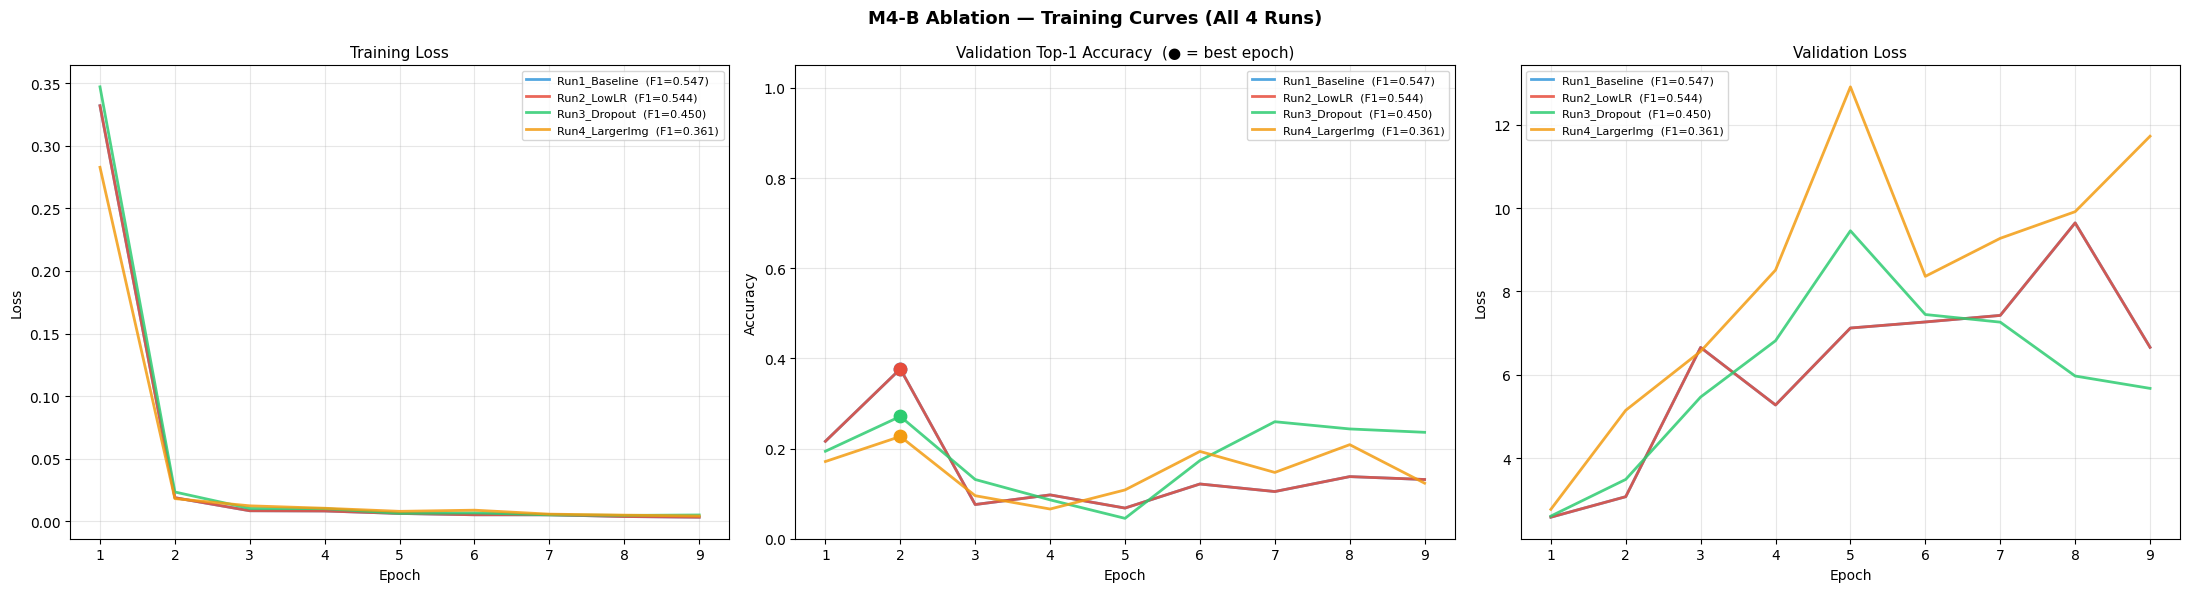


Final 5 epochs — Validation Accuracy:
  Epoch     Run1_Baseline         Run2_LowLR            Run3_Dropout          Run4_LargerImg      
  ------------------------------------------------------------------------------------------
  5         0.0680               0.0680               0.0452               0.1082             
  6         0.1214               0.1214               0.1734               0.1937             
  7         0.1047               0.1047               0.2595               0.1470             
  8         0.1378               0.1378               0.2435               0.2086             
  9         0.1314               0.1314               0.2360               0.1232             


In [9]:
# ── Training curves: all 4 runs overlaid ─────────────────────────────────────
COLORS = ['#3498DB','#E74C3C','#2ECC71','#F39C12']

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

for res, color in zip(all_results, COLORS):
    df = res['df_curves']
    if df.empty: continue
    epochs_x = range(1, len(df)+1)
    label    = f'{res["name"]}  (F1={res["weighted_f1"]:.3f})'

    # Loss
    for col in ['train/loss','train_loss']:
        if col in df.columns:
            axes[0].plot(epochs_x, df[col], color=color,
                         linewidth=2, label=label, alpha=0.85)
            break

    # Top-1 Accuracy
    for col in ['metrics/accuracy_top1','val/acc_top1','metrics/acc_top1']:
        if col in df.columns:
            axes[1].plot(epochs_x, df[col], color=color,
                         linewidth=2, label=label, alpha=0.85)
            # Mark best epoch
            best_ep = df[col].idxmax()
            axes[1].scatter(best_ep+1, df[col].iloc[best_ep],
                            color=color, s=80, zorder=5)
            break

    # Val Loss
    for col in ['val/loss','metrics/val_loss']:
        if col in df.columns:
            axes[2].plot(epochs_x, df[col], color=color,
                         linewidth=2, label=label, alpha=0.85)
            break

for ax, title, ylabel in [
    (axes[0], 'Training Loss',     'Loss'),
    (axes[1], 'Validation Top-1 Accuracy  (● = best epoch)', 'Accuracy'),
    (axes[2], 'Validation Loss',   'Loss'),
]:
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

axes[1].set_ylim(0, 1.05)

plt.suptitle('M4-B Ablation — Training Curves (All 4 Runs)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Epoch-by-epoch accuracy table (final 5 epochs of each run) ───────────────
print('\nFinal 5 epochs — Validation Accuracy:')
print(f'  {"Epoch":<8}', end='')
for res in all_results:
    print(f'  {res["name"][:18]:<20}', end='')
print()
print('  ' + '-'*90)

# Find max epochs
max_ep = max(len(r['df_curves']) for r in all_results if not r['df_curves'].empty)
show_from = max(0, max_ep - 5)

for ep_i in range(show_from, max_ep):
    print(f'  {ep_i+1:<8}', end='')
    for res in all_results:
        df = res['df_curves']
        if df.empty or ep_i >= len(df):
            print(f'  {"—":<20}', end='')
            continue
        for col in ['metrics/accuracy_top1','val/acc_top1','metrics/acc_top1']:
            if col in df.columns:
                val = df[col].iloc[ep_i]
                mark = ' ← best' if ep_i == df[col].idxmax() else ''
                print(f'  {val:.4f}{mark:<13}', end='')
                break
        else:
            print(f'  {"—":<20}', end='')
    print()

## 8) Evaluation on Validation Set

In [11]:
from sklearn.metrics import classification_report, precision_recall_fscore_support

# ── Per-run classification report ────────────────────────────────────────────
eval_summaries = []

for res in all_results:
    y_t = res['y_true']; y_p = res['y_pred']
    prec, rec, f1, sup = precision_recall_fscore_support(
        y_t, y_p, labels=list(range(len(TARGET_CLASSES))), zero_division=0)
    acc = accuracy_score(y_t, y_p)
    wf1 = f1_score(y_t, y_p, average='weighted', zero_division=0)

    eval_summaries.append({
        'name': res['name'], 'description': res['description'],
        'acc': acc, 'wf1': wf1,
        'prec': prec, 'rec': rec, 'f1': f1,
        'best_epoch': res['best_epoch'],
        'elapsed_s': res['elapsed_s'],
        'lr0': res['lr0'], 'batch': res['batch'],
        'imgsz': res['imgsz'], 'dropout': res['dropout'],
    })

# ── Master comparison table ───────────────────────────────────────────────────
print('='*85)
print('  ABLATION STUDY — ALL RUNS COMPARISON')
print('  Metric: Weighted F1 on validation set (↑ better)')
print('='*85)
print(f'  {"Run":<22} {"lr0":>7} {"batch":>6} {"imgsz":>6} {"drop":>5} '
      f'{"BestEp":>7} {"ValAcc":>8} {"WtdF1":>8}  Winner')
print('  ' + '-'*78)

best_f1 = max(s['wf1'] for s in eval_summaries)
for s in eval_summaries:
    crown = '🏆' if s['wf1'] == best_f1 else '  '
    print(f'  {s["name"]:<22} {s["lr0"]:>7.4f} {s["batch"]:>6} {s["imgsz"]:>6} '
          f'{s["dropout"]:>5.1f} {s["best_epoch"]:>7} '
          f'{s["acc"]:>8.4f} {s["wf1"]:>8.4f}  {crown}')
print('='*85)

# ── Per-class breakdown for best run ─────────────────────────────────────────
best_s = max(eval_summaries, key=lambda s: s['wf1'])
print(f'\nPer-class breakdown — {best_s["name"]} (best):')
print(f'  {"Class":<14} {"Precision":>10} {"Recall":>10} {"F1":>10}')
print('  ' + '-'*48)
for i, cls in enumerate(TARGET_CLASSES):
    print(f'  {cls:<14} {best_s["prec"][i]:>10.4f} '
          f'{best_s["rec"][i]:>10.4f} {best_s["f1"][i]:>10.4f}')

print(f'\nFull classification report — {best_s["name"]}:')
best_res = next(r for r in all_results if r['name']==best_s['name'])
print(classification_report(best_res['y_true'], best_res['y_pred'],target_names=TARGET_CLASSES, zero_division=0))

  ABLATION STUDY — ALL RUNS COMPARISON
  Metric: Weighted F1 on validation set (↑ better)
  Run                        lr0  batch  imgsz  drop  BestEp   ValAcc    WtdF1  Winner
  ------------------------------------------------------------------------------
  Run1_Baseline           0.0100     32    224   0.0       2   0.3767   0.5472  🏆
  Run2_LowLR              0.0010     32    224   0.0       2   0.3733   0.5437    
  Run3_Dropout            0.0010     32    224   0.3       2   0.2900   0.4496    
  Run4_LargerImg          0.0010     16    320   0.3       2   0.2200   0.3607    

Per-class breakdown — Run1_Baseline (best):
  Class           Precision     Recall         F1
  ------------------------------------------------
  Fighting           0.0000     0.0000     0.0000
  Assault            1.0000     0.3767     0.5472
  Normal             0.0000     0.0000     0.0000

Full classification report — Run1_Baseline:


ValueError: Number of classes, 2, does not match size of target_names, 3. Try specifying the labels parameter

## 9) Confusion Matrix

C:\Users\jingy\AppData\Local\Temp\ipykernel_13328\1656595571.py:9: RuntimeWarning: invalid value encountered in divide
  cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)


ValueError: The number of FixedLocator locations (2), usually from a call to set_ticks, does not match the number of labels (3).

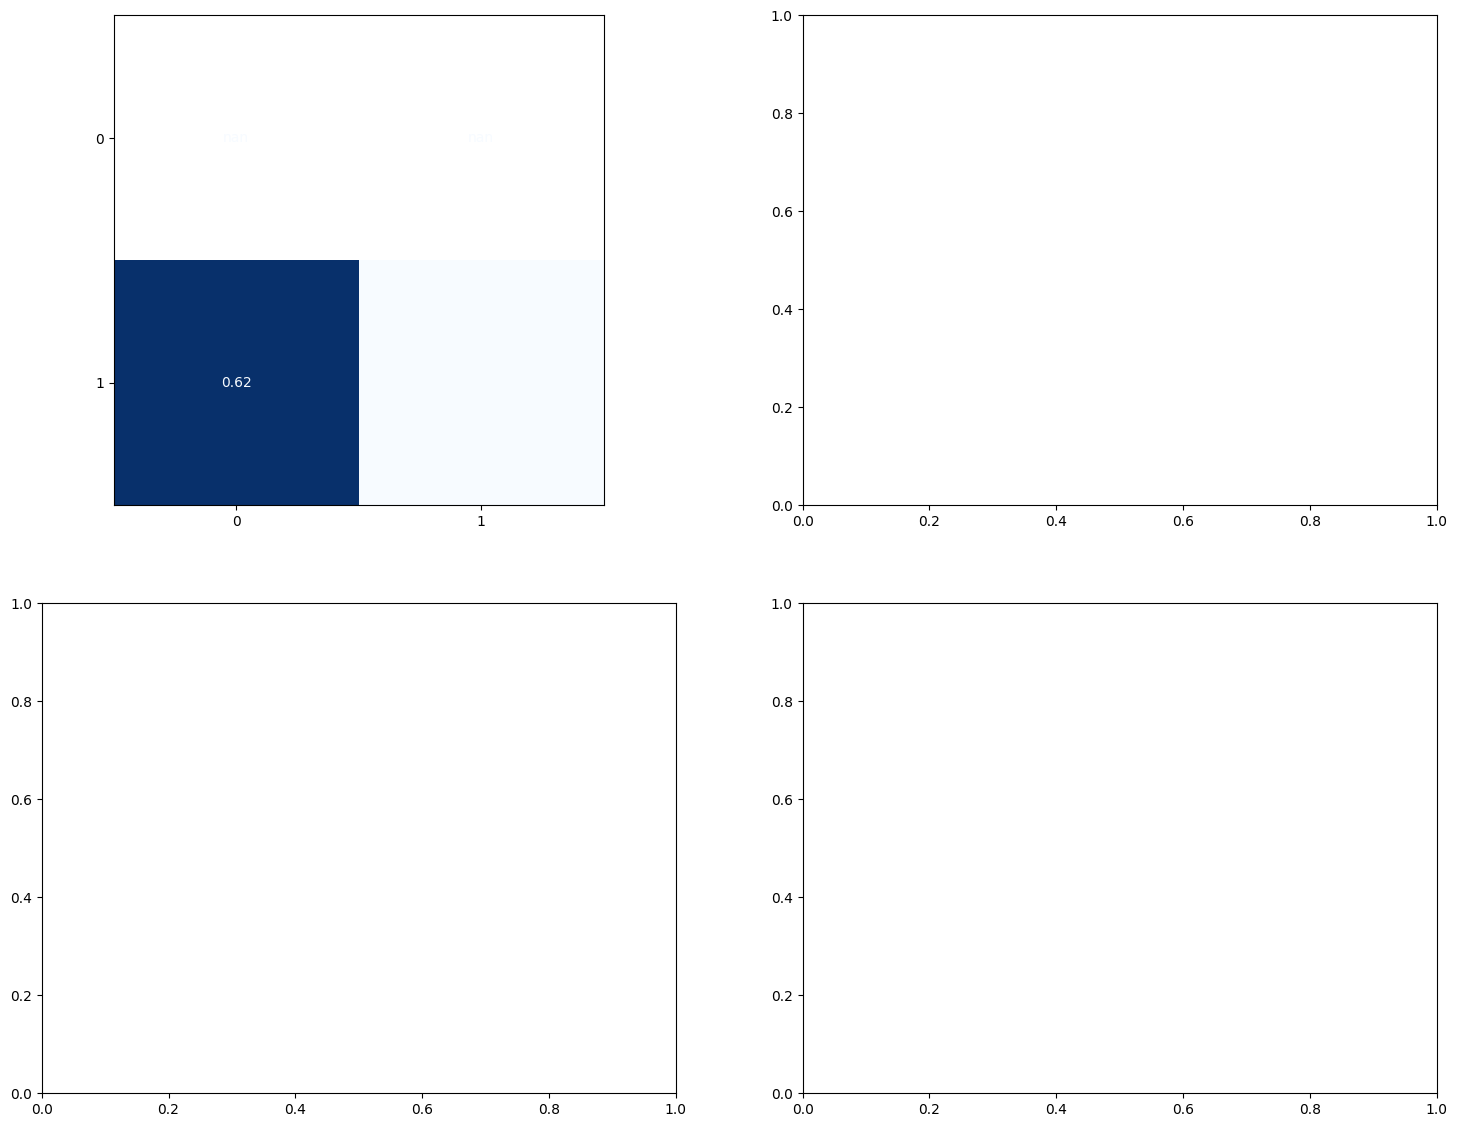

In [12]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# ── 2×2 confusion matrix grid (all runs) ─────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

for ax, res in zip(axes.flatten(), all_results):
    y_t = res['y_true']; y_p = res['y_pred']
    cm  = confusion_matrix(y_t, y_p)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    disp = ConfusionMatrixDisplay(cm_norm, display_labels=TARGET_CLASSES)
    disp.plot(ax=ax, colorbar=False, cmap='Blues', values_format='.2f')

    s    = next(s for s in eval_summaries if s['name']==res['name'])
    crown = '🏆 ' if s['wf1'] == best_f1 else ''
    ax.set_title(f'{crown}{res["name"]}'
                 f'lr={res["lr0"]}  batch={res["batch"]}  '
                 f'imgsz={res["imgsz"]}  dropout={res["dropout"]}'
                 f'Val Acc={s["acc"]:.4f}  Weighted F1={s["wf1"]:.4f}',
                 fontsize=9)

plt.suptitle('Confusion Matrices — Normalised (row = recall per class) All 4 Ablation Runs',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 10) Per-Class Metric Bar Chart

In [ ]:
# ── Grouped bar chart: F1 per class, all 4 runs ───────────────────────────────
COLORS = ['#3498DB','#E74C3C','#2ECC71','#F39C12']

x  = np.arange(len(TARGET_CLASSES))
w  = 0.18
n  = len(all_results)

fig, axes = plt.subplots(1, 2, figsize=(22, 7))

# Left — F1 per class per run
for i, (res, color) in enumerate(zip(all_results, COLORS)):
    s    = next(s for s in eval_summaries if s['name']==res['name'])
    bars = axes[0].bar(x + (i - n/2 + 0.5)*w, s['f1'], w,
                       label=res['name'], color=color, alpha=0.85)
    axes[0].bar_label(bars, fmt='%.3f', padding=3, fontsize=7, rotation=90)

axes[0].set_xticks(x)
axes[0].set_xticklabels(TARGET_CLASSES, fontsize=11)
axes[0].set_ylim(0, 1.35)
axes[0].set_ylabel('F1 Score')
axes[0].set_title('Per-Class F1 — All Runs', fontsize=11)
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', alpha=0.3)

# Right — Summary: ValAcc + WeightedF1 side by side per run
run_names = [r['name'].replace('Run','R') for r in all_results]
accs = [s['acc'] for s in eval_summaries]
wf1s = [s['wf1'] for s in eval_summaries]
xr   = np.arange(len(all_results))

b1 = axes[1].bar(xr - 0.2, accs, 0.35, label='Val Accuracy',   color='#3498DB', alpha=0.85)
b2 = axes[1].bar(xr + 0.2, wf1s, 0.35, label='Weighted F1',    color='#E74C3C', alpha=0.85)
axes[1].bar_label(b1, fmt='%.4f', padding=3, fontsize=9)
axes[1].bar_label(b2, fmt='%.4f', padding=3, fontsize=9)
axes[1].set_xticks(xr)
axes[1].set_xticklabels(run_names, fontsize=9, rotation=15)
axes[1].set_ylim(0, 1.2)
axes[1].set_ylabel('Score')
axes[1].set_title('Overall Val Accuracy & Weighted F1 per Run', fontsize=11)
axes[1].legend(fontsize=10)
axes[1].grid(axis='y', alpha=0.3)

# Highlight best bar
best_i = np.argmax(wf1s)
axes[1].patches[len(all_results) + best_i].set_edgecolor('#FFD700')
axes[1].patches[len(all_results) + best_i].set_linewidth(3)

plt.suptitle('M4-B Ablation Study — Performance Comparison'
             'All 4 Hyperparameter Configurations',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 11) Confidence Score Distribution
Shows how confident the model is on correct vs incorrect predictions.

In [ ]:
# Confidence distribution for the BEST run only
best_res_obj = next(r for r in all_results if r['name']==best_run['name'])

# Re-run inference with confidence scores (ablation eval subsampled — redo full)
val_model  = YOLO(M4B_WEIGHTS)
y_true_f, y_pred_f, y_conf_f = [], [], []
val_root   = Path(FRAMES_ROOT) / 'val'

for ci, cls in enumerate(TARGET_CLASSES):
    cls_dir = val_root / cls
    if not cls_dir.exists(): continue
    for img_path in cls_dir.glob('*.jpg'):
        res      = val_model(str(img_path), imgsz=best_run['imgsz'],
                             verbose=False)[0]
        pred_nm  = res.names[res.probs.top1]
        pred_idx = TARGET_CLASSES.index(pred_nm) if pred_nm in TARGET_CLASSES else -1
        y_true_f.append(ci); y_pred_f.append(pred_idx)
        y_conf_f.append(float(res.probs.top1conf))

y_true_f = np.array(y_true_f)
y_pred_f = np.array(y_pred_f)
y_conf_f = np.array(y_conf_f)

correct_conf   = y_conf_f[y_true_f == y_pred_f]
incorrect_conf = y_conf_f[y_true_f != y_pred_f]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(correct_conf,   bins=40, color='#2ECC71', alpha=0.8,
             label=f'Correct   n={len(correct_conf):,}')
axes[0].hist(incorrect_conf, bins=40, color='#E74C3C', alpha=0.8,
             label=f'Incorrect n={len(incorrect_conf):,}')
axes[0].axvline(0.5, color='black', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Confidence'); axes[0].set_ylabel('Count')
axes[0].set_title(f'Confidence Distribution\n{best_run["name"]} (best)')
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

class_confs = [y_conf_f[y_true_f==i].tolist() for i in range(len(TARGET_CLASSES))]
bp = axes[1].boxplot(class_confs, labels=TARGET_CLASSES, patch_artist=True)
for patch, c in zip(bp['boxes'], ['#3498DB','#E74C3C','#2ECC71']):
    patch.set_facecolor(c); patch.set_alpha(0.7)
axes[1].set_ylabel('Confidence'); axes[1].axhline(0.5, color='grey', linestyle='--')
axes[1].set_title('Per-Class Confidence — Best Run'); axes[1].grid(axis='y', alpha=0.3)

plt.suptitle(f'M4-B Confidence Analysis — {best_run["name"]}',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Mean confidence — Correct  : {correct_conf.mean():.4f}')
print(f'Mean confidence — Incorrect: {incorrect_conf.mean():.4f}')
print(f'Separation gap             : {correct_conf.mean()-incorrect_conf.mean():.4f}')

## 12) Final Summary & Integration Guide

In [ ]:
from sklearn.metrics import precision_recall_fscore_support

best_s   = next(s for s in eval_summaries if s['name']==best_run['name'])
prec, rec, f1, sup = precision_recall_fscore_support(
    y_true_f, y_pred_f,
    labels=list(range(len(TARGET_CLASSES))), zero_division=0)

SEP = '='*70
print(SEP)
print('  M4-B ABLATION STUDY — FINAL RESULTS')
print(f'  Dataset: UCF-Crime  |  Classes: {TARGET_CLASSES}')
print(f'  Base model: {BASE_MODEL}  |  Runs: {len(EXPERIMENTS)}')
print(SEP)
print()
print(f'  {"Run":<22} {"lr0":>7} {"batch":>6} {"imgsz":>6} {"drop":>5} '
      f'{"BestEp":>7} {"ValAcc":>9} {"WtdF1":>9}')
print('  ' + '-'*76)
for s in eval_summaries:
    crown = '🏆' if s['wf1'] == best_f1 else '  '
    print(f'  {s["name"]:<22} {s["lr0"]:>7.4f} {s["batch"]:>6} {s["imgsz"]:>6} '
          f'{s["dropout"]:>5.1f} {s["best_epoch"]:>7} '
          f'{s["acc"]:>9.4f} {s["wf1"]:>9.4f}  {crown}')
print()
print(SEP)
print(f'  🏆 BEST RUN : {best_run["name"]}')
print(f'     {best_run["description"]}')
print(f'     lr0={best_run["lr0"]}  batch={best_run["batch"]}  '
      f'imgsz={best_run["imgsz"]}  dropout={best_run["dropout"]}')
print(f'     Val Accuracy  : {best_s["acc"]:.4f}')
print(f'     Weighted F1   : {best_s["wf1"]:.4f}')
print(f'     Best epoch    : {best_s["best_epoch"]} / {best_run["epochs"]}')
print(f'     Weights saved : {M4B_WEIGHTS}')
print()
print(f'  Per-class (best run):')
print(f'  {"Class":<14} {"Precision":>10} {"Recall":>10} {"F1":>10} {"Support":>10}')
print('  ' + '-'*58)
for i, cls in enumerate(TARGET_CLASSES):
    print(f'  {cls:<14} {prec[i]:>10.4f} {rec[i]:>10.4f} '
          f'{f1[i]:>10.4f} {int(sup[i]):>10,}')
print()
print(SEP)
print('  PIPELINE INTEGRATION')
print(SEP)
print(f'  M4B_WEIGHTS    = r\'{M4B_WEIGHTS}\'')
print(f'  TARGET_CLASSES = {TARGET_CLASSES}')
print( '  M4B_CONF_THRESH = 0.50')
print()
print( '  def m4b_predict(frame):')
print( '      res = m4b_model(frame, verbose=False)[0]')
print( '      cls_name = TARGET_CLASSES[res.probs.top1]')
print( '      conf     = float(res.probs.top1conf)')
print( '      return cls_name, conf, cls_name != \'Normal\' and conf > M4B_CONF_THRESH')
print()
print(SEP)
print('  FYP WRITE-UP NOTES')
print(SEP)
print('  Table 1: Hyperparameter ablation — use the comparison table above')
print('  Table 2: Per-class metrics of best run — use the per-class table above')
print('  Figure:  Training curves + confusion matrix grids already generated')
print('  M4-A handles loitering (rule-based, dwell-time > 10s)')
print('  M4-B handles active threats (ML, Fighting/Assault detection)')
print('  Either channel triggers M5 → ALERT')